In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv(r"Documents/python basic/customer-churn-prediction-ml/")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\kanuc\\Documents\\python basic\\customer_churn-1\\customer_churn.csv'

In [ ]:
df

In [84]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [85]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [86]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [87]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [88]:
df.dropna(inplace=True)

In [89]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [90]:
df.drop(columns=['customerID'],inplace=True)

In [91]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [92]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [93]:
df.shape

(7032, 20)

In [95]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [96]:
col_list=[]
for col in df.columns:
  print(col)

gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [97]:
col_list=[]
for col in df.columns:
  if((df[col].dtype=='object')&(col!='Churn')):
    col_list.append(col)
print(col_list)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Tasks to be done:

A) Data Manipulation:

a. Find the total number of male customers

b. Find the total number of customers whose Internet Service is ‘DSL’

c. Extract all the Female senior citizens whose Payment Method is Mailed check & store the result in ‘new_customer’

d. Extract all those customers whose tenure is less than 10 months or their Total charges is less than 500$ & store the result in ‘new_customer’

In [98]:
Total_male_customers=(df['gender']=='Male').sum()


In [99]:
Total_male_customers

3549

In [100]:
# b. Find the total number of customers whose Internet Service is ‘DSL’
(df['PhoneService']=='DSL').sum()

0

In [101]:
##c. Extract all the Female senior citizens whose Payment Method is Mailed check & store the result in ‘new_customer’
df['PaymentMethod'].value_counts()


Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: PaymentMethod, dtype: int64

In [102]:
new_customer=(df['PaymentMethod']=='Mailed check').sum()
new_customer


1604

In [103]:
#d. Extract all those customers whose tenure is
#less than 10 months or their Total charges is less than 500$ & store the result in ‘new_customer’
new_customer=(df['tenure']<10) & (df['TotalCharges']<500)
new_customer.sum()

1621

B) Data Visualization:

a. Build a pie-chart to show the distribution of customers would be churning out

b. Build a bar-plot to show the distribution of ‘Internet Service’

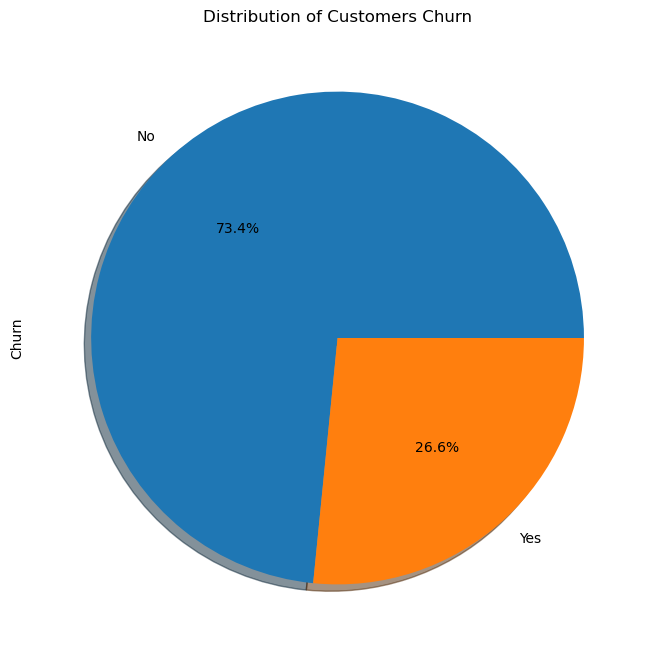

In [104]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
df['Churn'].value_counts().plot(kind='pie',figsize=(10,8),autopct='%1.1f%%',shadow=True)
plt.title('Distribution of Customers Churn')
plt.show()

b. Build a bar-plot to show the distribution of ‘Internet Service’

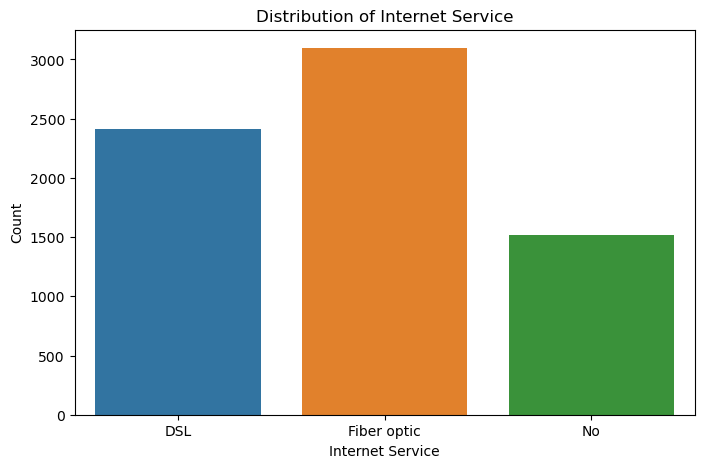

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', data=df)
plt.title('Distribution of Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.show()

In [107]:
from sklearn.preprocessing import LabelEncoder

In [108]:
l1=LabelEncoder()

In [109]:
for i in col_list:
  df[i]=l1.fit_transform(df[i])

In [110]:
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,No
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,No
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,Yes
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,No
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,Yes
5,0,0,0,0,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.50,Yes
6,1,0,0,1,22,1,2,1,0,2,0,0,2,0,0,1,1,89.10,1949.40,No
7,0,0,0,0,10,0,1,0,2,0,0,0,0,0,0,0,3,29.75,301.90,No
8,0,0,1,0,28,1,2,1,0,0,2,2,2,2,0,1,2,104.80,3046.05,Yes
9,1,0,0,1,62,1,0,0,2,2,0,0,0,0,1,0,0,56.15,3487.95,No


In [111]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int32  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   int32  
 3   Dependents        7032 non-null   int32  
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   int32  
 6   MultipleLines     7032 non-null   int32  
 7   InternetService   7032 non-null   int32  
 8   OnlineSecurity    7032 non-null   int32  
 9   OnlineBackup      7032 non-null   int32  
 10  DeviceProtection  7032 non-null   int32  
 11  TechSupport       7032 non-null   int32  
 12  StreamingTV       7032 non-null   int32  
 13  StreamingMovies   7032 non-null   int32  
 14  Contract          7032 non-null   int32  
 15  PaperlessBilling  7032 non-null   int32  
 16  PaymentMethod     7032 non-null   int32  


In [112]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})

In [124]:
X = df.drop('Churn', axis=1)

In [125]:
# Target variable
y = df['Churn']

print(y.head())
print(y.unique())
print(y.isnull().sum())

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64
[0 1]
0


In [127]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=43
)

In [129]:
X=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

In [130]:
X

array([[0.0000e+00, 0.0000e+00, 1.0000e+00, ..., 2.0000e+00, 2.9850e+01,
        2.9850e+01],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 3.0000e+00, 5.6950e+01,
        1.8895e+03],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 3.0000e+00, 5.3850e+01,
        1.0815e+02],
       ...,
       [0.0000e+00, 0.0000e+00, 1.0000e+00, ..., 2.0000e+00, 2.9600e+01,
        3.4645e+02],
       [1.0000e+00, 1.0000e+00, 1.0000e+00, ..., 3.0000e+00, 7.4400e+01,
        3.0660e+02],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0565e+02,
        6.8445e+03]])

In [131]:
y

array([0, 0, 1, ..., 0, 1, 0], dtype=int64)

In [133]:
import numpy as np

print("NaN in X_train:", np.isnan(X_train).sum())
print("NaN in y_train:", np.isnan(y_train).sum())

NaN in X_train: gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64
NaN in y_train: 0


In [134]:
# Check X_train
print(X_train.isnull().sum().sum())

# Check y_train
print(y_train.isnull().sum())

0
0


In [135]:
from sklearn.model_selection import train_test_split

In [136]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=43)

In [137]:
from sklearn.ensemble import RandomForestClassifier

In [138]:
rf1=RandomForestClassifier(n_estimators=100)

In [139]:
rf1

RandomForestClassifier()

In [140]:
rf1=rf1.fit(X_train,y_train)

In [141]:
y_pred=rf1.predict(X_test)

In [142]:
y_pred

array([0, 1, 0, ..., 1, 1, 0], dtype=int64)

In [143]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

0.7903340440653873

In [144]:
# confusion matrix, classification report

In [147]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
cm=confusion_matrix(y_test,y_pred)

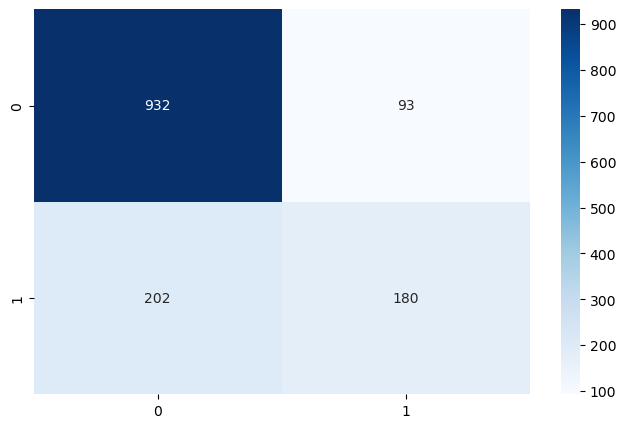

In [148]:
plt.figure(figsize=(8,5))
sns.heatmap(cm,annot=True,cmap='Blues',fmt='d')
plt.show()

In [149]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1025
           1       0.66      0.47      0.55       382

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [151]:
clf_rf=RandomForestClassifier(random_state=42,n_jobs=-1,max_depth=5,n_estimators=100,oob_score=True)
clf_rf

RandomForestClassifier(max_depth=5, n_jobs=-1, oob_score=True, random_state=42)

In [152]:
##  hyperparameter tuning using GridSearchCV
rf=RandomForestClassifier(random_state=42,n_jobs=-1)

In [153]:
params={
       'max_depth':[2,3,5,10,20],
    'min_samples_leaf':[5,10,20,50,100,200],
    'n_estimators':[10,25,30,50,100,200]
}

In [154]:
from sklearn.model_selection import GridSearchCV

In [155]:
grid_search=GridSearchCV(estimator=rf,param_grid=params,cv=4,n_jobs=-1,verbose=1,scoring='accuracy')

In [156]:
%%time
grid_search.fit(X_train,y_train)

Fitting 4 folds for each of 180 candidates, totalling 720 fits
CPU times: total: 2.69 s
Wall time: 57.5 s


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5, 10, 20],
                         'min_samples_leaf': [5, 10, 20, 50, 100, 200],
                         'n_estimators': [10, 25, 30, 50, 100, 200]},
             scoring='accuracy', verbose=1)

In [157]:
grid_search.best_score_

0.8064005819308254

Using Adabooster Classifier

In [158]:
from sklearn.ensemble import AdaBoostClassifier
clf=AdaBoostClassifier(n_estimators=100,learning_rate=1,random_state=0)

In [159]:
clf.fit(X_train,y_train)

AdaBoostClassifier(learning_rate=1, n_estimators=100, random_state=0)

In [160]:
pred_val=clf.predict(X_test)

In [161]:
print(accuracy_score(y_test,pred_val))

0.7903340440653873


Using XGbooster Classifier

In [162]:
from xgboost import XGBClassifier
xgb=XGBClassifier(n_estimators=100,learning_rate=1,random_state=0)

In [163]:
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=0, ...)

In [164]:
xgb_pred=xgb.predict(X_test)

In [165]:
print(accuracy_score(y_test,xgb_pred))

0.7761194029850746


In [1]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'AdaBoost', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, pred_val),
        accuracy_score(y_test, xgb_pred)
    ]
})

results.sort_values(by='Accuracy', ascending=False)

NameError: name 'pd' is not defined